### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn as sns
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from scipy.sparse import issparse
import decoupler as dc
from sklearn.preprocessing import QuantileTransformer
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.preprocessing import QuantileTransformer, StandardScaler
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
scaler = StandardScaler()

import warnings
warnings.filterwarnings("ignore")

In [ ]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, frameon=False)
sc._settings.ScanpyConfig.n_jobs=70

In [ ]:
import os
os.environ["R_HOME"] = "/home/yangshichen//mambaforge/envs/QTL/lib/R"
os.environ["R_LIBS_USER"] = "/home/yangshichen/mambaforge/envs/QTL/lib/R/library"
import pandas as pd
import torch
import tensorqtl
from tensorqtl import trans,rfunc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} (CUDA {torch.version.cuda}), device: {device}")
print(f"pandas: {pd.__version__}")

### Use tensorqtl-eQTL

#### Read genotype_df and vatiant_df

In [4]:
genotype_df_all = pd.read_parquet('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_genotype.parquet')
variant_df_all = pd.read_parquet('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_variant_df.parquet')
variant_df_all['chrom'] = 'chr' + variant_df_all['chrom'].astype(str)

#### Run tensorqtl

In [5]:
#设置bed文件所在的文件夹路径
bed_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/06.gene_expression_bed/'
output_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/trans-eQTL/'

#获取所有以.bed结尾的文件
bed_files = [f for f in os.listdir(bed_dir) if f.endswith('.bed')]

In [6]:
len(bed_files)

99

In [7]:
# 遍历文件，处理并创建对应文件夹
for bed_file in bed_files:
    cell_name = os.path.splitext(bed_file)[0]  # 去掉.bed后缀

    #筛选需要检测的位点
    lead_esnp_all_df =  pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv',index_col=0) 
    lead_esnp_all_df = lead_esnp_all_df[lead_esnp_all_df["celltype"] == cell_name]
    lead_esnp_celltype = lead_esnp_all_df['variant_id'].unique()
    genotype_df = genotype_df_all.loc[genotype_df_all.index.isin(lead_esnp_celltype),]
    variant_df = variant_df_all.loc[variant_df_all.index.isin(lead_esnp_celltype),]
    
    #read_expression_file and covariates
    expression_bed = f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/06.gene_expression_bed/{cell_name}.bed'
    covariates_file = f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/05.PEER/01.factor/{cell_name}.csv'

    #load phenotypes and covariates
    #align phenotypes and covariates
    phenotype_df, phenotype_pos_df = tensorqtl.read_phenotype_bed(expression_bed)
    covariates_df = pd.read_csv(covariates_file, sep=',', index_col=0)
    phenotype_df = phenotype_df[covariates_df.index]

    #decited the number of peer factor
    sample_size = covariates_df.shape[0]
    if sample_size <= 150:
        PF = list('PF' + str(i) for i in range(1, 16))
    elif sample_size <= 250:
        PF = list('PF' + str(i) for i in range(1, 31))
    elif sample_size <= 350:
        PF = list('PF' + str(i) for i in range(1, 46))
    elif sample_size > 350:
        PF = list('PF' + str(i) for i in range(1, 61))
        info = list(['Gender', 'Age', 'Batch', 'Pregnancy', 'PC1', 'PC2'])
        cova_need = info + PF
        covariates_df = covariates_df.loc[:,cova_need]

    #trans-QTL mapping
    trans_df = trans.map_trans(genotype_df, phenotype_df, covariates_df, batch_size=5000,
                               return_sparse=True, pval_threshold=1, maf_threshold=0.1)

    trans_df['variant_chr'] = trans_df['variant_id'].str.split(':').str[0].str.replace('chr', '')
    trans_df['phenotype_chr'] = phenotype_pos_df.loc[trans_df['phenotype_id'],'chr'].values
    trans_df['phenotype_chr'] = trans_df['phenotype_chr'].str.replace('chr', '', regex=False)
    trans_df['celltype'] = cell_name
    trans_df.to_parquet(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/trans-eQTL/{cell_name}.parquet')

trans-QTL mapping
  * 815 samples
  * 13189 phenotypes
  * 66 covariates
  * 4466 variants
    processing batch 1/1
    elapsed time: 0.34 min
  * 4466 variants passed MAF >= 0.1 filtering
done.
trans-QTL mapping
  * 845 samples
  * 12123 phenotypes
  * 66 covariates
  * 4070 variants
    processing batch 1/1
    elapsed time: 0.30 min
  * 4070 variants passed MAF >= 0.1 filtering
done.
trans-QTL mapping
  * 781 samples
  * 2289 phenotypes
  * 66 covariates
  * 140 variants
    processing batch 1/1
    elapsed time: 0.00 min
  * 140 variants passed MAF >= 0.1 filtering
done.
trans-QTL mapping
  * 793 samples
  * 1156 phenotypes
  * 66 covariates
  * 74 variants
    processing batch 1/1
    elapsed time: 0.00 min
  * 74 variants passed MAF >= 0.1 filtering
done.
trans-QTL mapping
  * 797 samples
  * 2678 phenotypes
  * 66 covariates
  * 171 variants
    processing batch 1/1
    elapsed time: 0.01 min
  * 171 variants passed MAF >= 0.1 filtering
done.
trans-QTL mapping
  * 815 samples
  

### 处理trans-eQTL

In [4]:
#设置bed文件所在的文件夹路径
bed_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/06.gene_expression_bed/'
output_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/trans-eQTL/'
#获取所有以.bed结尾的文件
bed_files = [f for f in os.listdir(bed_dir) if f.endswith('.bed')]
eqtl_celltype = [os.path.splitext(f)[0] for f in bed_files]

In [5]:
dfs = []
for celltype in eqtl_celltype:
    print(f'reading_{celltype}')
    trans_df = pd.read_parquet(f'{output_dir}/{celltype}.parquet')
    dfs.append(trans_df)

trans_df_all = pd.concat(dfs, axis=0, ignore_index=True)

reading_Adaptive NK cells
reading_ALPL- MARCKS- NDNs
reading_ASDC
reading_Atypical naïve B cells
reading_Basophils
reading_CCR4+ CD8+ Tcm
reading_CCR4- CD8+ Tcm
reading_CD14+ cDC2
reading_CD177int iLDNs
reading_CD1C+ cDC2
reading_CD27+ IgD+ atypical memory B cells
reading_CD27+ IgD- atypical memory B cells
reading_CD27+ MAIT
reading_CD27+ Th1
reading_CD27+ Th17
reading_CD27- IgD- atypical memory B cells
reading_CD27- Th1
reading_CD27- Th17
reading_CD279+ SOX4+ Vδ1+ T cells
reading_CD4+ Temra
reading_CD56+ MAIT
reading_CD56bright NK cells
reading_CD56dim NK cells
reading_CD62Lhi GZMK+ Vδ2+ T cells
reading_CD8+ Temra
reading_CD8+ Treg
reading_CD95 memory B cells
reading_cDC1
reading_CILCP
reading_CLP
reading_Core classical monocytes
reading_Core NDNs
reading_DN T cells
reading_Early memory B cells
reading_FOS- NDNs
reading_GBP1+ classical monocytes
reading_GZMB+ CD4+ terminal effector T cells
reading_GZMB+ CD8+ Tem
reading_GZMB+ Vδ2+ T cells
reading_GZMK+ CD8+ Tem
reading_GZMK+ effector 

In [6]:
trans_df_all

,variant_id,phenotype_id,pval,b,b_se,af,variant_chr,phenotype_chr,celltype
0,1:913469:G:C,LINC01409,1.174357e-06,0.376520,0.076837,0.102454,1,1,Adaptive NK cells
1,1:913469:G:C,LINC00115,1.345393e-21,0.754035,0.076565,0.102454,1,1,Adaptive NK cells
2,1:913469:G:C,LINC01128,8.959913e-39,0.965222,0.069921,0.102454,1,1,Adaptive NK cells
3,1:913469:G:C,NOC2L,1.154577e-01,0.102335,0.064935,0.102454,1,1,Adaptive NK cells
4,1:913469:G:C,KLHL17,1.571280e-01,0.112723,0.079594,0.102454,1,1,Adaptive NK cells
...,...,...,...,...,...,...,...,...,...
1488988109,22:50583334:G:C,TYMP,9.325063e-01,0.005450,0.064334,0.144963,22,22,vNKT
1488988110,22:50583334:G:C,CPT1B,1.357987e-04,-0.226350,0.059012,0.144963,22,22,vNKT
1488988111,22:50583334:G:C,CHKB,1.588496e-23,0.662549,0.064053,0.144963,22,22,vNKT
1488988112,22:50583334:G:C,ARSA,6.981287e-04,0.199760,0.058674,0.144963,22,22,vNKT


### 筛选下游结果

#### 去除同一条染色体上的结果

In [7]:
trans_df_all = trans_df_all[trans_df_all['variant_chr'] != trans_df_all['phenotype_chr']]
trans_df_all.loc[:,'pair'] = trans_df_all['variant_id'].astype(str) + '_' + trans_df_all['phenotype_id'].astype(str)
trans_df_all

,variant_id,phenotype_id,pval,b,b_se,af,variant_chr,phenotype_chr,celltype,pair
1389,1:913469:G:C,FAM110C,0.838742,-0.013862,0.068093,0.102454,1,2,Adaptive NK cells,1:913469:G:C_FAM110C
1390,1:913469:G:C,SH3YL1,0.977040,0.001757,0.061029,0.102454,1,2,Adaptive NK cells,1:913469:G:C_SH3YL1
1391,1:913469:G:C,ACP1,0.263706,0.067486,0.060336,0.102454,1,2,Adaptive NK cells,1:913469:G:C_ACP1
1392,1:913469:G:C,ALKAL2,0.666136,-0.032604,0.075537,0.102454,1,2,Adaptive NK cells,1:913469:G:C_ALKAL2
1393,1:913469:G:C,TMEM18,0.395530,0.050067,0.058894,0.102454,1,2,Adaptive NK cells,1:913469:G:C_TMEM18
...,...,...,...,...,...,...,...,...,...,...
1488987887,22:50583334:G:C,MCM3AP,0.298226,-0.063449,0.060951,0.144963,22,21,vNKT,22:50583334:G:C_MCM3AP
1488987888,22:50583334:G:C,YBEY,0.526170,0.039333,0.062024,0.144963,22,21,vNKT,22:50583334:G:C_YBEY
1488987889,22:50583334:G:C,PCNT,0.689578,-0.026504,0.066328,0.144963,22,21,vNKT,22:50583334:G:C_PCNT
1488987890,22:50583334:G:C,DIP2A,0.995425,-0.000378,0.065877,0.144963,22,21,vNKT,22:50583334:G:C_DIP2A


#### 计算BH

In [8]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

In [9]:
trans_df_all.loc[:,'padj'] = multipletests(trans_df_all['pval'], method='fdr_bh')[1]
trans_df_all_sig = trans_df_all[trans_df_all['padj'] < 0.05].reset_index(drop = True)
trans_df_all_sig['variant_celltype'] = trans_df_all_sig['variant_id']+"_"+trans_df_all_sig['celltype']
trans_df_all_sig

,variant_id,phenotype_id,pval,b,b_se,af,variant_chr,phenotype_chr,celltype,pair,padj,variant_celltype
0,1:19644233:C:G,NEK10,1.934989e-11,0.300081,0.044028,0.465031,1,3,Adaptive NK cells,1:19644233:C:G_NEK10,2.093101e-05,1:19644233:C:G_Adaptive NK cells
1,1:19670687:A:C,NEK10,3.619674e-11,0.333236,0.049593,0.287117,1,3,Adaptive NK cells,1:19670687:A:C_NEK10,3.754221e-05,1:19670687:A:C_Adaptive NK cells
2,1:45521902:C:A,MELK,5.945268e-08,-0.312675,0.057099,0.138037,1,9,Adaptive NK cells,1:45521902:C:A_MELK,2.847577e-02,1:45521902:C:A_Adaptive NK cells
3,1:61112473:T:A,DBN1,2.484298e-08,0.270255,0.047962,0.186503,1,5,Adaptive NK cells,1:61112473:T:A_DBN1,1.359966e-02,1:61112473:T:A_Adaptive NK cells
4,2:42102571:C:G,CRIP1,4.346250e-09,-0.249443,0.041988,0.234969,2,14,Adaptive NK cells,2:42102571:C:G_CRIP1,2.971699e-03,2:42102571:C:G_Adaptive NK cells
...,...,...,...,...,...,...,...,...,...,...,...,...
3371,3:52005208:A:G,SLC35F1,5.329842e-60,0.959355,0.053533,0.124079,3,6,vNKT,3:52005208:A:G_SLC35F1,6.062922e-53,3:52005208:A:G_vNKT
3372,3:194656983:C:T,RNF34,8.923110e-08,-0.255832,0.047369,0.206388,3,12,vNKT,3:194656983:C:T_RNF34,3.955537e-02,3:194656983:C:T_vNKT
3373,6:34432037:T:C,AMBRA1,4.983165e-22,-0.390212,0.039174,0.446560,6,11,vNKT,6:34432037:T:C_AMBRA1,1.619589e-15,6:34432037:T:C_vNKT
3374,12:56042145:C:G,DAB1,7.543528e-23,0.489439,0.048116,0.248772,12,1,vNKT,12:56042145:C:G_DAB1,2.563987e-16,12:56042145:C:G_vNKT


#### 合并cis-eQTL的结果

In [10]:
lead_esnp_all_df =  pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv',index_col=0) 
lead_esnp_all_df['variant_celltype'] = lead_esnp_all_df['variant_id']+"_"+lead_esnp_all_df['celltype']
lead_esnp_all_df

,Unnamed: 1,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,...,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold,variant_celltype
1,0,LINC01409,2098,1.014873,175.46053,633.22360,7.667730e-06,1:913469:G:C,134721,103404,...,0.376520,0.076837,0.0012,1.210901e-03,Adaptive NK cells,1.590819e-03,0.000345,3.700370e-03,0.000138,1:913469:G:C_Adaptive NK cells
2,1,LINC00115,2110,1.034240,184.23022,638.61804,1.084343e-18,1:913469:G:C,89240,85930,...,0.754036,0.076565,0.0001,5.709014e-17,Adaptive NK cells,2.350422e-16,0.000349,5.632009e-16,0.000142,1:913469:G:C_Adaptive NK cells
3,2,LINC01128,2155,1.033578,190.25635,638.34015,2.224656e-33,1:913469:G:C,88330,54023,...,0.965222,0.069921,0.0001,3.985215e-32,Adaptive NK cells,3.243837e-31,0.000338,7.682978e-31,0.000137,1:913469:G:C_Adaptive NK cells
6,5,PLEKHN1,2442,1.012655,203.74387,639.77124,9.955614e-06,1:967724:C:T,1241,-8141,...,0.251579,0.052275,0.0012,1.863383e-03,Adaptive NK cells,2.363903e-03,0.000295,5.501332e-03,0.000118,1:967724:C:T_Adaptive NK cells
7,6,HES4,2544,1.040256,206.67317,632.98000,3.134341e-16,1:1000079:A:G,1116,-93,...,0.580657,0.063696,0.0001,1.874707e-14,Adaptive NK cells,6.650379e-14,0.000318,1.603061e-13,0.000130,1:1000079:A:G_Adaptive NK cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522671,522670,MLC1,3982,1.022432,377.21906,642.96990,3.719965e-08,22:50162190:C:T,102798,76764,...,-0.244703,0.040776,0.0001,1.081672e-05,vNKT,2.140447e-04,0.000015,4.449209e-05,0.000066,22:50162190:C:T_vNKT
522674,522673,TUBGCP6,3448,1.063128,306.44360,625.85580,9.352160e-06,22:50285139:T:C,67449,40116,...,-0.238750,0.048939,0.0018,1.923142e-03,vNKT,2.309970e-02,0.000023,5.664238e-03,0.000096,22:50285139:T:C_vNKT
522677,522676,SBF1,2672,1.054757,210.89390,626.79877,4.379444e-07,22:50394500:G:A,-48720,-89423,...,-0.253763,0.045559,0.0001,5.421682e-05,vNKT,9.308642e-04,0.000031,2.037004e-04,0.000134,22:50394500:G:A_vNKT
522682,522681,CPT1B,2397,1.057882,156.10364,609.17630,2.964191e-15,22:50579047:A:G,10185,582,...,-0.367232,0.040959,0.0001,8.716872e-14,vNKT,4.386658e-12,0.000043,7.146178e-13,0.000184,22:50579047:A:G_vNKT


In [11]:
lead_snp_egene = lead_esnp_all_df.groupby('variant_celltype')['phenotype_id'].agg(';'.join).reset_index()
lead_snp_egene = lead_snp_egene.rename(columns={'phenotype_id': 'cis_eGene'})
lead_snp_egene

,variant_celltype,cis_eGene
0,10:1012256:C:T_GZMK+ CD8+ Tem,WDR37
1,10:1018471:G:A_CD27+ Th1,IDI1
2,10:1018471:G:A_CD8+ Temra,GTPBP4;IDI1;WDR37
3,10:1018471:G:A_GZMB+ CD4+ terminal effector T ...,IDI1
4,10:1018471:G:A_GZMB+ CD8+ Tem,LARP4B;IDI1
...,...,...
129399,9:99198507:A:G_ALPL- MARCKS- NDNs,TGFBR1
129400,9:99318720:C:T_ALPL- MARCKS- NDNs,SEC61B
129401,9:99401604:T:A_CD8+ Temra,TEX10
129402,9:99966726:A:G_FOS- NDNs,INVS


In [12]:
trans_df_all_sig_merge = pd.merge(trans_df_all_sig, lead_snp_egene, on='variant_celltype', how='inner')
trans_df_all_sig_merge['trans_eGene'] = trans_df_all_sig_merge['phenotype_id']
trans_df_all_sig_merge

,variant_id,phenotype_id,pval,b,b_se,af,variant_chr,phenotype_chr,celltype,pair,padj,variant_celltype,cis_eGene,trans_eGene
0,1:19644233:C:G,NEK10,1.934989e-11,0.300081,0.044028,0.465031,1,3,Adaptive NK cells,1:19644233:C:G_NEK10,2.093101e-05,1:19644233:C:G_Adaptive NK cells,NBL1,NEK10
1,1:19670687:A:C,NEK10,3.619674e-11,0.333236,0.049593,0.287117,1,3,Adaptive NK cells,1:19670687:A:C_NEK10,3.754221e-05,1:19670687:A:C_Adaptive NK cells,TMCO4,NEK10
2,1:45521902:C:A,MELK,5.945268e-08,-0.312675,0.057099,0.138037,1,9,Adaptive NK cells,1:45521902:C:A_MELK,2.847577e-02,1:45521902:C:A_Adaptive NK cells,PRDX1,MELK
3,1:61112473:T:A,DBN1,2.484298e-08,0.270255,0.047962,0.186503,1,5,Adaptive NK cells,1:61112473:T:A_DBN1,1.359966e-02,1:61112473:T:A_Adaptive NK cells,NFIA,DBN1
4,2:42102571:C:G,CRIP1,4.346250e-09,-0.249443,0.041988,0.234969,2,14,Adaptive NK cells,2:42102571:C:G_CRIP1,2.971699e-03,2:42102571:C:G_Adaptive NK cells,EML4,CRIP1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,3:52005208:A:G,SLC35F1,5.329842e-60,0.959355,0.053533,0.124079,3,6,vNKT,3:52005208:A:G_SLC35F1,6.062922e-53,3:52005208:A:G_vNKT,RPL29,SLC35F1
3372,3:194656983:C:T,RNF34,8.923110e-08,-0.255832,0.047369,0.206388,3,12,vNKT,3:194656983:C:T_RNF34,3.955537e-02,3:194656983:C:T_vNKT,LSG1,RNF34
3373,6:34432037:T:C,AMBRA1,4.983165e-22,-0.390212,0.039174,0.446560,6,11,vNKT,6:34432037:T:C_AMBRA1,1.619589e-15,6:34432037:T:C_vNKT,RPS10,AMBRA1
3374,12:56042145:C:G,DAB1,7.543528e-23,0.489439,0.048116,0.248772,12,1,vNKT,12:56042145:C:G_DAB1,2.563987e-16,12:56042145:C:G_vNKT,RPS26,DAB1


In [13]:
trans_df_all_sig_merge.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/trans_eQTL_fdr005.csv')

### 数据统计

#### plot1

In [1]:
library(ggplot2)
library(future)
library(tidyverse)
library(ggpubr)
library(ggchicklet)
library(ggsci)
library(magrittr)
library(ggh4x)
library(rstatix)
library(ggsignif)
library(ggnewscale)
library(patchwork)
library(gapminder)
library(ggprism)
library(dplyr)
library(ggplotify)
library(readr)
library(arrow)
library(ggbreak)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

载入程序包：‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract



载入程序包：‘rstatix’


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘arrow’


The following object is masked from ‘package:magrittr’:

    is_in


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:utils’:

    timestamp


ggbreak v0.1.5 Learn more 

In [30]:
mytheme <- theme_prism(base_family="",base_fontface="plain") +
  theme(strip.text = element_text(size = 8,angle=10,vjust = 0.5,hjust = 0.5),
        axis.line = element_line(color = "black",size = 0.2),
        axis.ticks = element_line(size = 0.2),
        axis.text.y = element_text(color = "black",size = 6),
        axis.text.x = element_text(color = "black",size = 6, angle = 30,hjust = 1,vjust = 1),
        axis.title = element_text(color = "black",size = 10),
        legend.position = "none")

In [3]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/trans_eQTL_fdr005.csv",check.names = F,header = T))
data

,variant_id,phenotype_id,pval,b,b_se,af,variant_chr,phenotype_chr,celltype,pair,padj,variant_celltype,cis_eGene,trans_eGene
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
0,1:19644233:C:G,NEK10,1.934989e-11,0.3000807,0.04402842,0.4650307,1,3,Adaptive NK cells,1:19644233:C:G_NEK10,2.093101e-05,1:19644233:C:G_Adaptive NK cells,NBL1,NEK10
1,1:19670687:A:C,NEK10,3.619674e-11,0.3332363,0.04959309,0.2871166,1,3,Adaptive NK cells,1:19670687:A:C_NEK10,3.754221e-05,1:19670687:A:C_Adaptive NK cells,TMCO4,NEK10
2,1:45521902:C:A,MELK,5.945268e-08,-0.3126745,0.05709865,0.1380368,1,9,Adaptive NK cells,1:45521902:C:A_MELK,2.847577e-02,1:45521902:C:A_Adaptive NK cells,PRDX1,MELK
3,1:61112473:T:A,DBN1,2.484298e-08,0.2702547,0.04796204,0.1865031,1,5,Adaptive NK cells,1:61112473:T:A_DBN1,1.359966e-02,1:61112473:T:A_Adaptive NK cells,NFIA,DBN1
4,2:42102571:C:G,CRIP1,4.346250e-09,-0.2494433,0.04198793,0.2349693,2,14,Adaptive NK cells,2:42102571:C:G_CRIP1,2.971699e-03,2:42102571:C:G_Adaptive NK cells,EML4,CRIP1
5,2:113487524:C:A,ZNG1A,2.029206e-51,-0.6226706,0.03816202,0.4901840,2,9,Adaptive NK cells,2:113487524:C:A_ZNG1A,1.947144e-44,2:113487524:C:A_Adaptive NK cells,ZNG1B,ZNG1A
6,3:39405803:A:C,RPSA2,6.304069e-72,0.6944366,0.03462068,0.2944785,3,19,Adaptive NK cells,3:39405803:A:C_RPSA2,9.459811e-65,3:39405803:A:C_Adaptive NK cells,RPSA,RPSA2
7,3:39494916:G:A,RPSA2,1.617611e-08,0.2490275,0.04360182,0.2349693,3,19,Adaptive NK cells,3:39494916:G:A_RPSA2,9.366692e-03,3:39494916:G:A_Adaptive NK cells,SLC25A38,RPSA2
8,3:52005208:A:G,SLC35F1,2.078630e-111,1.3334506,0.04974940,0.1239264,3,6,Adaptive NK cells,3:52005208:A:G_SLC35F1,6.818644e-104,3:52005208:A:G_Adaptive NK cells,RPL29,SLC35F1


In [4]:
data1 <- subset(data, celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs','Proliferative mLDNs'))
length(unique(data1$phenotype_id))

[1] 568

In [12]:
library(dplyr)

result <- data1[, c("phenotype_id", "celltype")] %>%
  group_by(phenotype_id) %>%
  summarise(n_celltype = n_distinct(celltype)) %>%
  mutate(
    share_group = case_when(
      n_celltype == 1 ~ "1",
      n_celltype >= 2 & n_celltype <= 5 ~ as.character(n_celltype),
      n_celltype >= 6 ~ ">=6"
    )
  ) %>%
  count(share_group)

result

share_group,n
<chr>,<int>
1,346
2,70
3,53
4,35
5,28
>=6,36


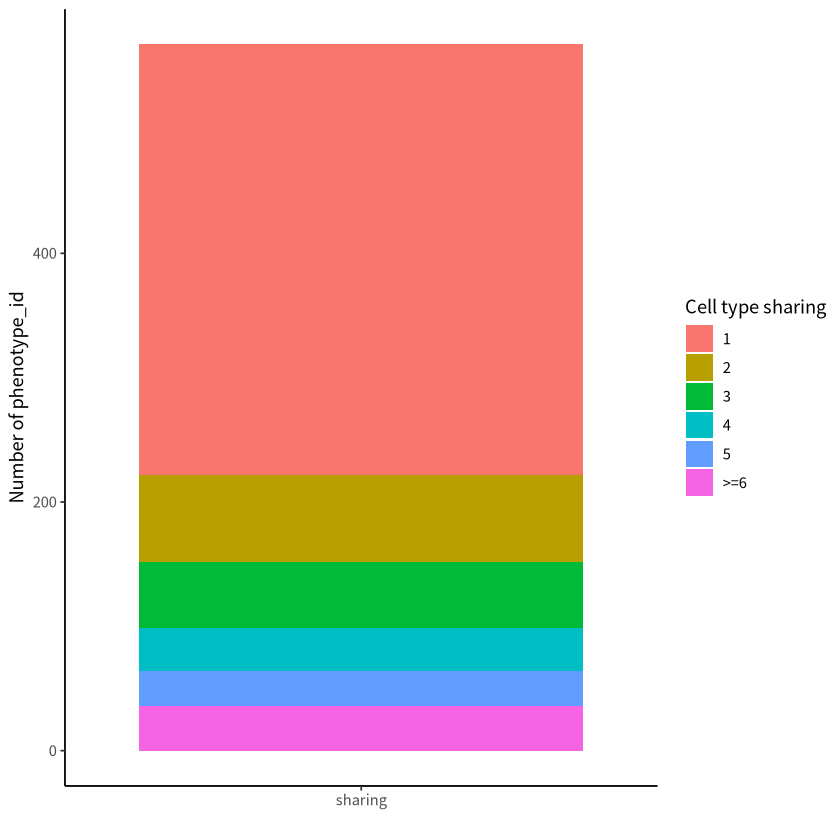

In [13]:
result$share_group <- factor(
  result$share_group,
  levels = c(as.character(1:5), ">=6")
)
p <- ggplot(result, aes(x = "sharing", y = n, fill = share_group)) +
  geom_bar(stat = "identity") +
  labs(x = "", y = "Number of phenotype_id", fill = "Cell type sharing") +
  theme_classic()
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/neu_egene_ratio.pdf",p,width=15,height=3)

In [5]:
data2 <- subset(data, !(celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs','Proliferative mLDNs')))
length(unique(data2$phenotype_id))

[1] 604

In [14]:
library(dplyr)

result <- data2[, c("phenotype_id", "celltype")] %>%
  group_by(phenotype_id) %>%
  summarise(n_celltype = n_distinct(celltype)) %>%
  mutate(
    share_group = case_when(
      n_celltype == 1 ~ "1",
      n_celltype >= 2 & n_celltype <= 9 ~ as.character(n_celltype),
      n_celltype >= 10 ~ ">=10"
    )
  ) %>%
  count(share_group)

result

share_group,n
<chr>,<int>
1,451
2,55
3,19
4,24
5,8
6,6
7,7
8,8
9,6


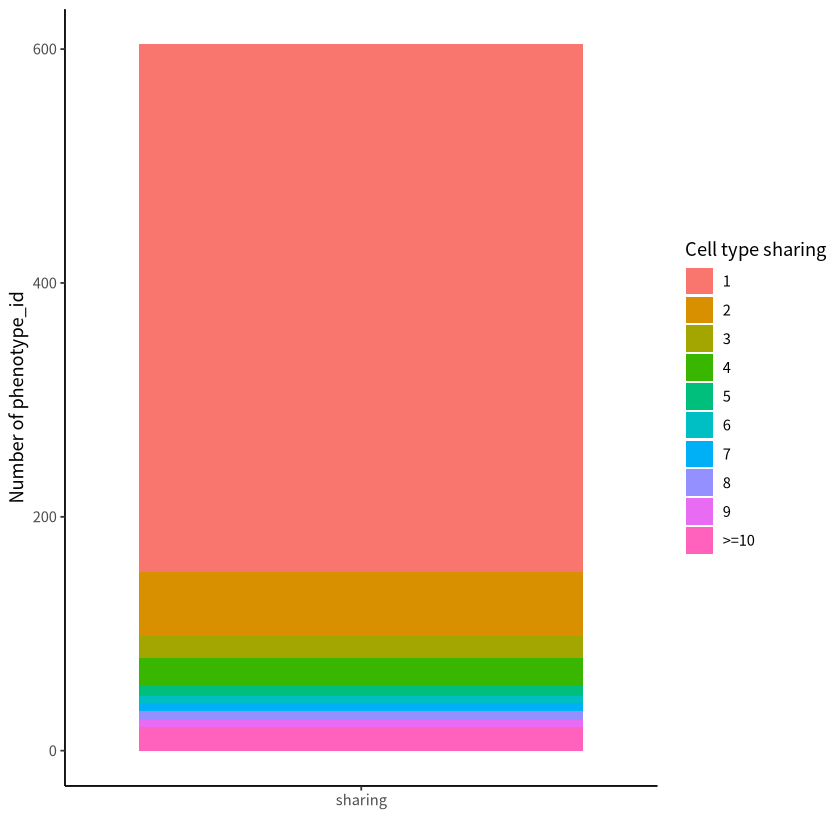

In [15]:
result$share_group <- factor(
  result$share_group,
  levels = c(as.character(1:9), ">=10")
)
p <- ggplot(result, aes(x = "sharing", y = n, fill = share_group)) +
  geom_bar(stat = "identity") +
  labs(x = "", y = "Number of phenotype_id", fill = "Cell type sharing") +
  theme_classic()
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/pbmc_egene_ratio.pdf",p,width=15,height=3)

In [6]:
# 每个 phenotype_id 出现在哪些 celltype
pheno_cell_map <- data %>%
  distinct(celltype, phenotype_id) %>%
  group_by(phenotype_id) %>%
  summarise(celltype_count = n(),
            celltypes = paste(sort(unique(celltype)), collapse = ",")) %>%
  ungroup()

In [7]:
# 特有的 phenotype_id
unique_phenos <- pheno_cell_map %>%
  filter(celltype_count == 1)

# 共享的 phenotype_id
shared_phenos <- pheno_cell_map %>%
  filter(celltype_count > 1)

In [8]:
# 合并 celltype 到 pheno 表
df_pheno_info <- data %>%
  distinct(celltype, phenotype_id) %>%
  left_join(pheno_cell_map, by = "phenotype_id")

# 每个 celltype 的统计
tmp <- df_pheno_info %>% group_by(celltype) %>%
       summarise(unique_phenotype_n = sum(celltype_count == 1),
                 shared_phenotype_n = sum(celltype_count > 1))
tmp$total_egenes <- tmp$unique_phenotype_n + tmp$shared_phenotype_n
colnames(tmp) <- c('celltype','unique_egenes','shared_egenes','total_egenes')
tmp$celltype <- factor(tmp$celltype,levels = c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP','LAMP3+ DC','Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                               'Proliferative mLDNs'))
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ALPL- MARCKS- NDNs,11,66,77
Adaptive NK cells,23,80,103
CCR4+ CD8+ Tcm,0,3,3
CCR4- CD8+ Tcm,0,3,3
CD14+ cDC2,0,8,8
CD1C+ cDC2,2,14,16
CD27+ IgD+ atypical memory B cells,1,3,4
CD27+ MAIT,0,4,4
CD27+ Th1,1,10,11


In [9]:
tmp_long <- tmp %>%
  pivot_longer(cols = c(unique_egenes, shared_egenes),
               names_to = "type",
               values_to = "count") %>%
  mutate(type = recode(type,
                       shared_egenes = "Shared eGenes",
                       unique_egenes = "Unique eGenes"))
tmp_long$type <- factor(tmp_long$type, levels = c('Unique eGenes','Shared eGenes'))
tmp_long

celltype,total_egenes,type,count
<fct>,<int>,<fct>,<int>
ALPL- MARCKS- NDNs,77,Unique eGenes,11
ALPL- MARCKS- NDNs,77,Shared eGenes,66
Adaptive NK cells,103,Unique eGenes,23
Adaptive NK cells,103,Shared eGenes,80
CCR4+ CD8+ Tcm,3,Unique eGenes,0
CCR4+ CD8+ Tcm,3,Shared eGenes,3
CCR4- CD8+ Tcm,3,Unique eGenes,0
CCR4- CD8+ Tcm,3,Shared eGenes,3
CD14+ cDC2,8,Unique eGenes,0


In [39]:
tmp_long1 <- subset(tmp_long, celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                    'Proliferative mLDNs'))
tmp_long1

celltype,total_egenes,type,count
<fct>,<int>,<fct>,<int>
ALPL- MARCKS- NDNs,77,Unique eGenes,11
ALPL- MARCKS- NDNs,77,Shared eGenes,66
CXCL8- PTGS2+ NDNs,102,Unique eGenes,11
CXCL8- PTGS2+ NDNs,102,Shared eGenes,91
Core NDNs,355,Unique eGenes,165
Core NDNs,355,Shared eGenes,190
FOS- NDNs,122,Unique eGenes,20
FOS- NDNs,122,Shared eGenes,102
IFIT2- RNF213- NDNs,15,Unique eGenes,4


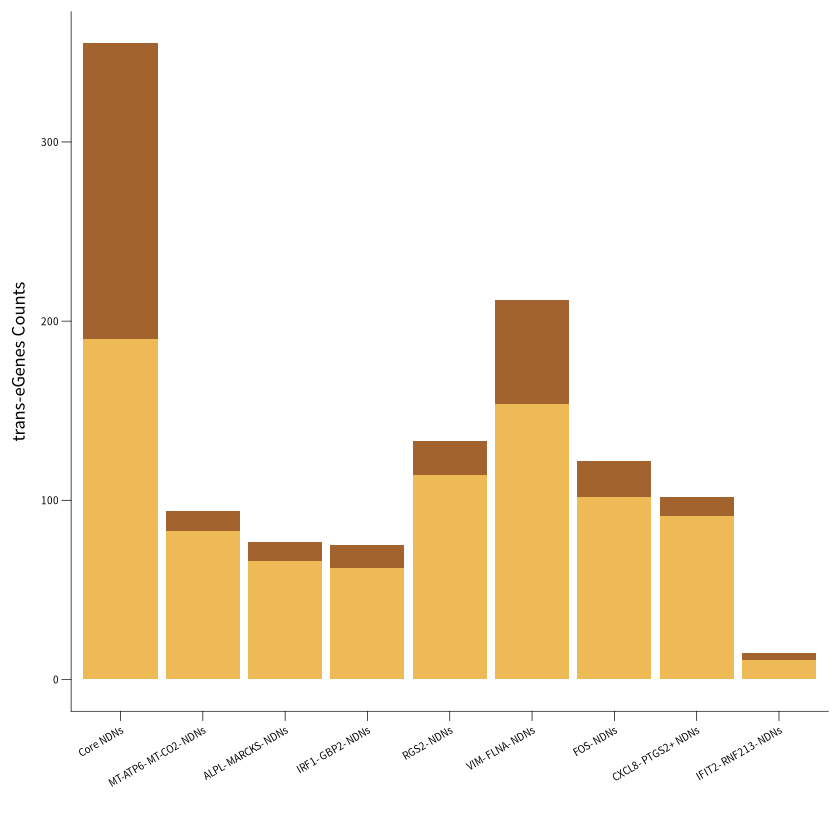

In [11]:
p <- ggplot(tmp_long1, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(x = "", y = "trans-eGenes Counts", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#A3632E", "Shared eGenes" = "#EDBA55")) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/neu_egene_count.pdf",p,width=10,height=3)

In [16]:
tmp2 <- subset(tmp, celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                    'LAMP3+ DC'))

In [40]:
tmp_long2 <- subset(tmp_long, celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                    'LAMP3+ DC'))
tmp_long2

celltype,total_egenes,type,count
<fct>,<int>,<fct>,<int>
Adaptive NK cells,103,Unique eGenes,23
Adaptive NK cells,103,Shared eGenes,80
CCR4+ CD8+ Tcm,3,Unique eGenes,0
CCR4+ CD8+ Tcm,3,Shared eGenes,3
CCR4- CD8+ Tcm,3,Unique eGenes,0
CCR4- CD8+ Tcm,3,Shared eGenes,3
CD14+ cDC2,8,Unique eGenes,0
CD14+ cDC2,8,Shared eGenes,8
CD1C+ cDC2,16,Unique eGenes,2


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”


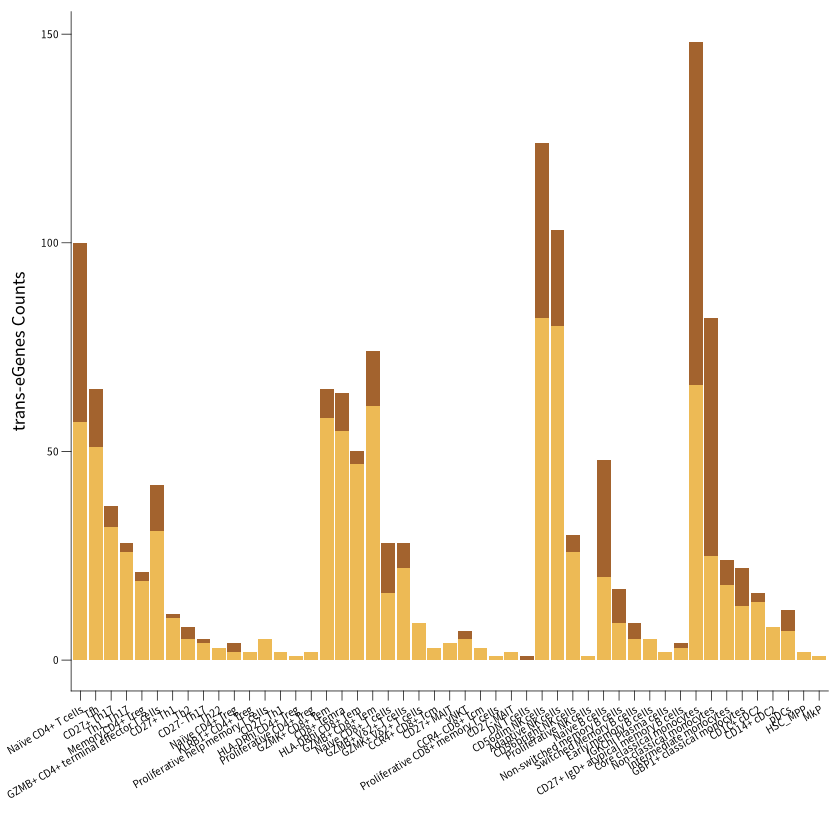

In [17]:
p <- ggplot(tmp_long2, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(x = "", y = "trans-eGenes Counts", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#A3632E", "Shared eGenes" = "#EDBA55")) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/pbmc_egene_count.pdf",p,width=10,height=3)

#### plot2

In [31]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv",check.names = F,header = T))
data

,.1,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,⋯,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold
<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,LINC01409,2098,1.014873,175.4605,633.2236,7.667730e-06,1:913469:G:C,134721,⋯,1.174355e-06,0.3765205,0.07683704,0.00119988,1.210901e-03,Adaptive NK cells,1.590819e-03,0.0003445664,3.700370e-03,1.377503e-04
2,1,LINC00115,2110,1.034240,184.2302,638.6180,1.084343e-18,1:913469:G:C,89240,⋯,1.345368e-21,0.7540356,0.07656465,0.00009999,5.709014e-17,Adaptive NK cells,2.350422e-16,0.0003494642,5.632009e-16,1.419710e-04
3,2,LINC01128,2155,1.033578,190.2563,638.3401,2.224656e-33,1:913469:G:C,88330,⋯,8.960126e-39,0.9652224,0.06992146,0.00009999,3.985215e-32,Adaptive NK cells,3.243837e-31,0.0003376822,7.682978e-31,1.371101e-04
6,5,PLEKHN1,2442,1.012655,203.7439,639.7712,9.955614e-06,1:967724:C:T,1241,⋯,1.803183e-06,0.2515789,0.05227502,0.00119988,1.863383e-03,Adaptive NK cells,2.363903e-03,0.0002945747,5.501332e-03,1.175416e-04
7,6,HES4,2544,1.040256,206.6732,632.9800,3.134341e-16,1:1000079:A:G,1116,⋯,7.069647e-19,0.5806572,0.06369613,0.00009999,1.874707e-14,Adaptive NK cells,6.650379e-14,0.0003175379,1.603061e-13,1.296284e-04
8,7,ISG15,2579,1.031593,217.5914,637.3262,1.278423e-08,1:1015903:C:T,14764,⋯,7.304698e-10,0.1901433,0.03046918,0.00009999,1.831833e-06,Adaptive NK cells,3.476263e-06,0.0002933993,8.237876e-06,1.189355e-04
10,9,C1orf159,2845,1.009523,256.2610,654.2985,9.117941e-05,1:1023789:G:C,-58030,⋯,2.900352e-05,-0.2388179,0.05676469,0.02209779,2.219327e-02,Adaptive NK cells,2.243731e-02,0.0002317901,4.951678e-02,9.224086e-05
11,10,TNFRSF18,2898,1.040453,221.8812,634.2929,4.812934e-52,1:1217733:G:A,14224,⋯,5.615811e-61,-0.7218388,0.03988647,0.00009999,1.096144e-51,Adaptive NK cells,1.675139e-50,0.0002959626,3.933917e-50,1.208391e-04
12,11,TNFRSF4,2913,1.052444,212.6466,626.4841,1.036046e-44,1:1217251:C:A,5924,⋯,5.620543e-53,-0.6538712,0.03936067,0.00009999,1.407439e-44,Adaptive NK cells,1.746132e-43,0.0003206232,4.087194e-43,1.321603e-04


In [32]:
# 每个 phenotype_id 出现在哪些 celltype
pheno_cell_map <- data %>%
  distinct(celltype, phenotype_id) %>%
  group_by(phenotype_id) %>%
  summarise(celltype_count = n(),
            celltypes = paste(sort(unique(celltype)), collapse = ",")) %>%
  ungroup()

In [33]:
# 特有的 phenotype_id
unique_phenos <- pheno_cell_map %>%
  filter(celltype_count == 1)

# 共享的 phenotype_id
shared_phenos <- pheno_cell_map %>%
  filter(celltype_count > 1)

In [34]:
# 合并 celltype 到 pheno 表
df_pheno_info <- data %>%
  distinct(celltype, phenotype_id) %>%
  left_join(pheno_cell_map, by = "phenotype_id")

# 每个 celltype 的统计
tmp <- df_pheno_info %>% group_by(celltype) %>%
       summarise(unique_phenotype_n = sum(celltype_count == 1),
                 shared_phenotype_n = sum(celltype_count > 1))
tmp$total_egenes <- tmp$unique_phenotype_n + tmp$shared_phenotype_n
colnames(tmp) <- c('celltype','unique_egenes','shared_egenes','total_egenes')
tmp$celltype <- factor(tmp$celltype,levels = c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP','LAMP3+ DC','Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                               'Proliferative mLDNs'))
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ALPL- MARCKS- NDNs,15,4182,4197
ASDC,0,140,140
Adaptive NK cells,52,4518,4570
Atypical naïve B cells,2,72,74
Basophils,8,163,171
CCR4+ CD8+ Tcm,11,893,904
CCR4- CD8+ Tcm,6,294,300
CD14+ cDC2,16,1851,1867
CD177int iLDNs,1,45,46


In [37]:
tmp <- tmp[,c(1,4)]
colnames(tmp)[2] <- 'cisegene'
tmp

celltype,cisegene
<fct>,<int>
ALPL- MARCKS- NDNs,4197
ASDC,140
Adaptive NK cells,4570
Atypical naïve B cells,74
Basophils,171
CCR4+ CD8+ Tcm,904
CCR4- CD8+ Tcm,300
CD14+ cDC2,1867
CD177int iLDNs,46


In [41]:
tmp_long1 <- unique(tmp_long1[,c(1,2)])
colnames(tmp_long1)[2] <- 'transegene'
tmp_long1

celltype,transegene
<fct>,<int>
ALPL- MARCKS- NDNs,77
CXCL8- PTGS2+ NDNs,102
Core NDNs,355
FOS- NDNs,122
IFIT2- RNF213- NDNs,15
IRF1- GBP2- NDNs,75
MT-ATP6- MT-CO2- NDNs,94
RGS2- NDNs,133
VIM- FLNA- NDNs,212


In [42]:
tmp_long2 <- unique(tmp_long2[,c(1,2)])
colnames(tmp_long2)[2] <- 'transegene'
tmp_long2

celltype,transegene
<fct>,<int>
Adaptive NK cells,103
CCR4+ CD8+ Tcm,3
CCR4- CD8+ Tcm,3
CD14+ cDC2,8
CD1C+ cDC2,16
CD27+ IgD+ atypical memory B cells,4
CD27+ MAIT,4
CD27+ Th1,11
CD27+ Th17,37


In [45]:
tmp_long1 <- tmp_long1 %>%
  left_join(tmp, by = "celltype")
tmp_long1

celltype,transegene,cisegene
<fct>,<int>,<int>
ALPL- MARCKS- NDNs,77,4197
CXCL8- PTGS2+ NDNs,102,2908
Core NDNs,355,6908
FOS- NDNs,122,2957
IFIT2- RNF213- NDNs,15,2108
IRF1- GBP2- NDNs,75,4196
MT-ATP6- MT-CO2- NDNs,94,4241
RGS2- NDNs,133,3828
VIM- FLNA- NDNs,212,3596


In [46]:
tmp_long2 <- tmp_long2 %>%
  left_join(tmp, by = "celltype")
tmp_long2

celltype,transegene,cisegene
<fct>,<int>,<int>
Adaptive NK cells,103,4570
CCR4+ CD8+ Tcm,3,904
CCR4- CD8+ Tcm,3,300
CD14+ cDC2,8,1867
CD1C+ cDC2,16,2335
CD27+ IgD+ atypical memory B cells,4,383
CD27+ MAIT,4,772
CD27+ Th1,11,968
CD27+ Th17,37,3326


In [49]:
tmp_long <- rbind(tmp_long1,tmp_long2)
tmp_long

celltype,transegene,cisegene
<fct>,<int>,<int>
ALPL- MARCKS- NDNs,77,4197
CXCL8- PTGS2+ NDNs,102,2908
Core NDNs,355,6908
FOS- NDNs,122,2957
IFIT2- RNF213- NDNs,15,2108
IRF1- GBP2- NDNs,75,4196
MT-ATP6- MT-CO2- NDNs,94,4241
RGS2- NDNs,133,3828
VIM- FLNA- NDNs,212,3596


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


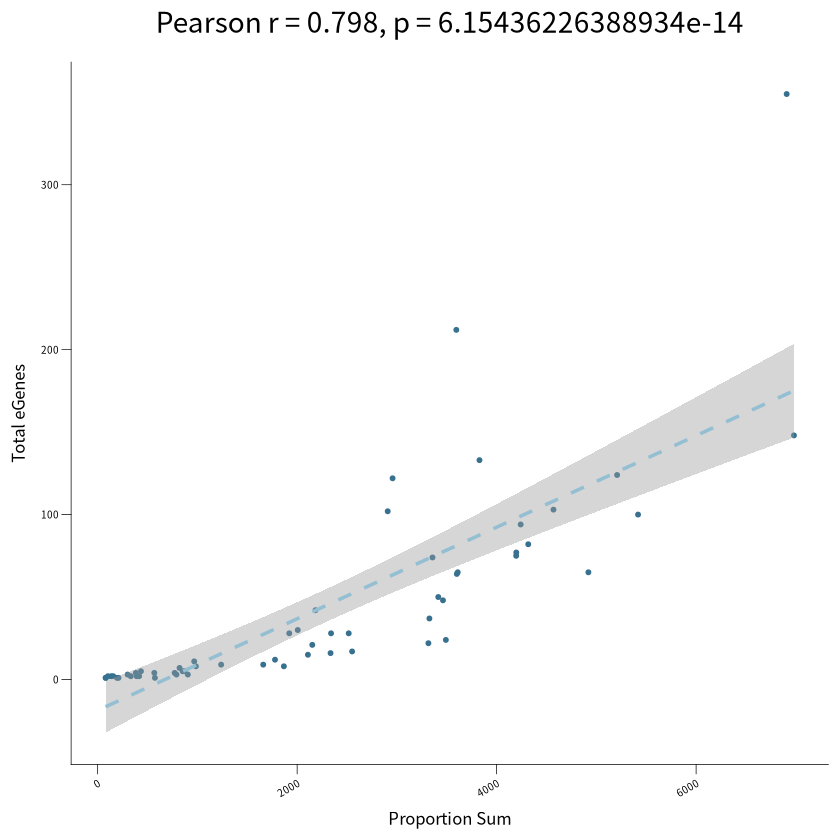

In [50]:
cor_test <- cor.test(tmp_long$transegene,
                     tmp_long$cisegene,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(tmp_long, aes(x = cisegene, y = transegene)) +
     geom_point(size=1,color = "#37718F") +
     geom_smooth(method = "lm", se = T, color = "#94BFD2", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/egene_cor_cellratio.pdf",p,width=3,height=3.5)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


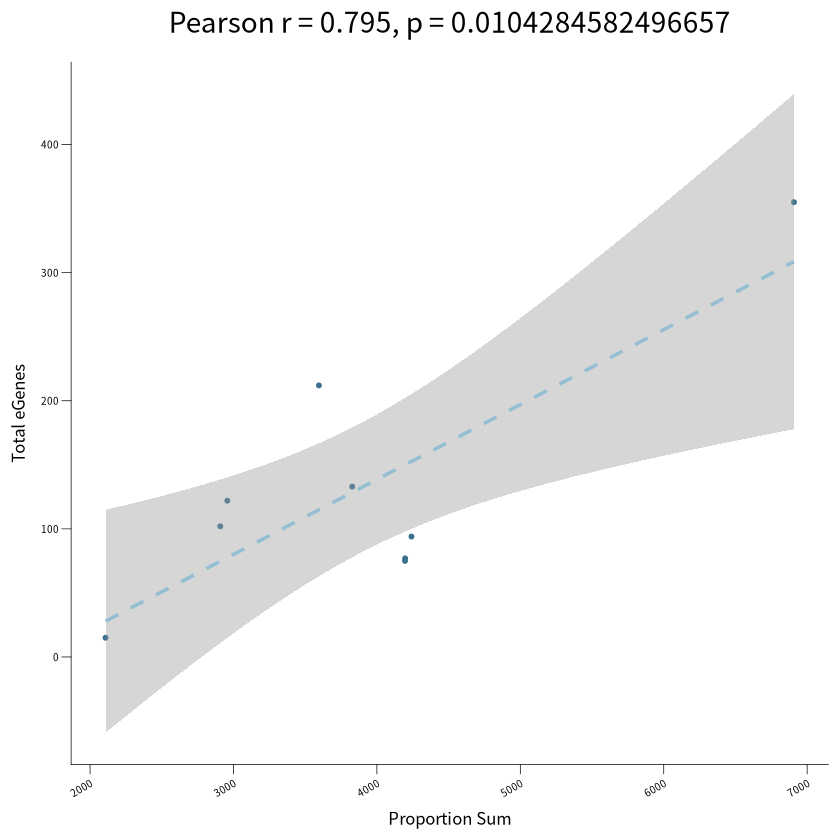

In [47]:
cor_test <- cor.test(tmp_long1$transegene,
                     tmp_long1$cisegene,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(tmp_long1, aes(x = cisegene, y = transegene)) +
     geom_point(size=1,color = "#37718F") +
     geom_smooth(method = "lm", se = T, color = "#94BFD2", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/pbmc_egene_cor_cellratio.pdf",p,width=3,height=3.5)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


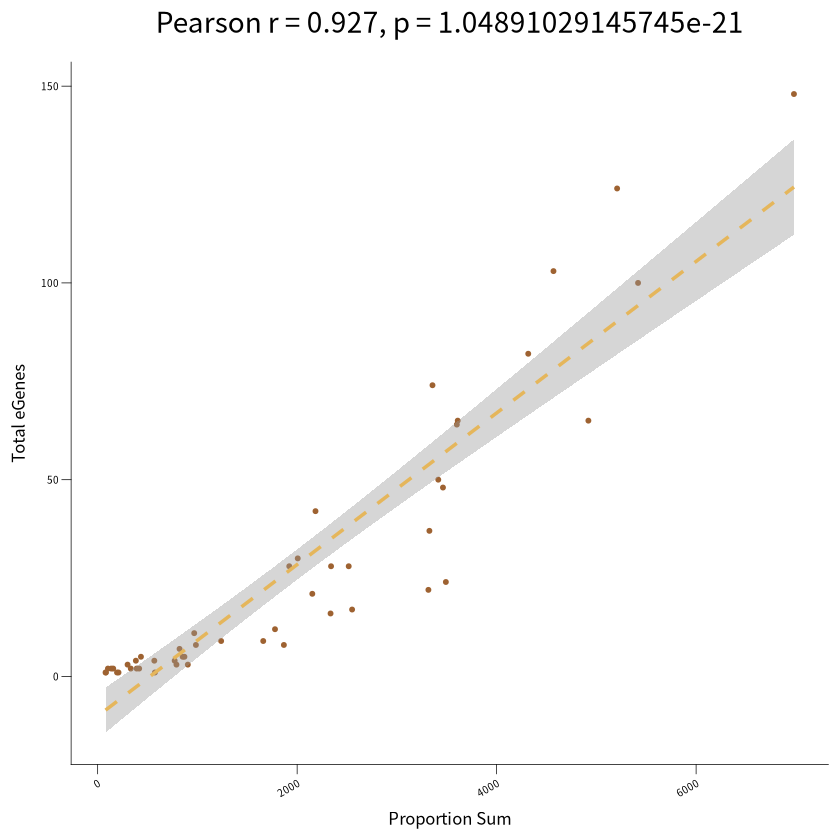

In [48]:
cor_test <- cor.test(tmp_long2$transegene,
                     tmp_long2$cisegene,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(tmp_long2, aes(x = cisegene, y = transegene)) +
     geom_point(size=1,color = "#9E6231") +
     geom_smooth(method = "lm", se = T, color = "#E5B65B", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/neu_egene_cor_cellratio.pdf",p,width=3,height=3.5)

### 举例

#### 1

In [9]:
phenotype_id <- c('FADD','NFKBIA','NFKBIZ','IER5','IER3')
variantid <- c('11:70201906:T:C','11:70201906:T:C','11:70201906:T:C','11:70201906:T:C','11:70201906:T:C')
pval_adj_bh <- c('5.51333949050987e-28','2.986313850936134e-09','6.435940843166842e-10','7.867254599372005e-09','4.095296163077751e-08')
celltype <- c('Core NDNs','Core NDNs','Core NDNs','Core NDNs','Core NDNs')

In [10]:
#变异信息
geno_data <- read_parquet("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_genotype.parquet")
sub_geno_data <- as.data.frame(t(subset(geno_data, variant_id %in% variantid)))
colnames(sub_geno_data) <- sub_geno_data[1,]
sub_geno_data <- sub_geno_data[-1, , drop = FALSE]

In [11]:
for (i in 1:length(phenotype_id)){
    sub_phenotype_id <- phenotype_id[i]
    sub_variant_id <- variantid[i]
    sub_pval_adj_bh <- pval_adj_bh[i]
    sub_celltype <- celltype[i]

    #基因信息
    gene_data <- read.csv(paste0("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/07.gene_expression_csv/",sub_celltype,".csv"))
    sub_gene_data <- subset(gene_data, gene_id %in% phenotype_id)
    sub_gene_data <- as.data.frame(t(sub_gene_data[,-c(1,2,3)]))
    colnames(sub_gene_data) <- sub_gene_data[1,]
    sub_gene_data <- sub_gene_data[-1, , drop = FALSE]
    rownames(sub_gene_data) <- gsub("\\.", "-", rownames(sub_gene_data))

    #信息合并
    sub_geno_data_tmp <- sub_geno_data[,sub_variant_id,drop = FALSE]
    sub_gene_data_tmp <- sub_gene_data[,sub_phenotype_id,drop = FALSE]
    merged_data <- cbind(sub_gene_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_gene_data_tmp)), , drop = FALSE],
                         sub_geno_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_geno_data_tmp)), , drop = FALSE])
    merged_data[[1]] <- as.numeric(merged_data[[1]])
    merged_data[[2]] <- as.numeric(merged_data[[2]])
    merged_data[[2]] <- factor(merged_data[[2]], levels = c("0", "1", "2"))

    #计算中位值
    medians <- merged_data %>%
    group_by(!!sym(names(merged_data)[2])) %>%
    summarize(med = median(.data[[names(merged_data)[1]]], na.rm = TRUE)) %>%
    ungroup()

    #作图
    p <- ggplot(merged_data, aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1]))) +
         geom_violin(trim = FALSE, scale = "width", fill = "#99C7DB") +
         geom_boxplot(width = 0.1, outlier.size = 0.5, position = position_dodge(0.9)) +
         geom_line(data = medians, aes(x = !!sym(names(medians)[1]), y = med, group = 1), size = 1,color = "#3A6FB0") +
         #geom_jitter(aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1])), size = 1, 
         #            position = position_jitter(width = 0.15, height = 0), color = "#3A6FB0") +
         labs(title = paste0("P = ",sub_pval_adj_bh,"; Celltype = ",sub_celltype), 
              x = colnames(merged_data)[2], y = colnames(merged_data)[1]) +
         mytheme
    ggsave(paste0('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/',sub_celltype,"_",sub_phenotype_id,"_",sub_variant_id,'.pdf'),p)
}

Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image


### circle

In [58]:
pdf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/trans/circle-2.pdf", width=5, height=5)
library(circlize)

circos.initializeWithIdeogram(species = "hg38")
circos.link("chr4", 103423205, "chr1", 40924555,)
circos.link("chr4", 103423205, "chr5", 179260556,)
circos.link("chr4", 103423205, "chr14", 94844924,)
circos.link("chr4", 103423205, "chr6", 31539774,)
circos.link("chr4", 103423205, "chr10", 104162074,)
circos.link("chr4", 103423205, "chr15", 63023511,)
circos.link("chr4", 103423205, "chr22", 37954372,)
circos.clear()

dev.off()

pdf 
  2

### 人群MAF比较

In [ ]:
bcftools query \
  -R my_snps.txt \
  -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AF\t%INFO/AF_EAS\t%INFO/AF_EUR\t%INFO/AF_AFR\t%INFO/AF_SAS\t%INFO/AF_AMR\t%INFO/AF_EUR_unrel\t%INFO/AF_EAS_unrel\t%INFO/AF_AMR_unrel\t%INFO/AF_SAS_unrel\t%INFO/AF_AFR_unrel\n' \
  1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz \
  > all_AF.txt

In [ ]:
bcftools query \
  -R my_snps.txt \
  -H \
  -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AF\t%INFO/AF_EUR_unrel\t%INFO/AF_EAS_unrel\t%INFO/AF_AMR_unrel\t%INFO/AF_SAS_unrel\t%INFO/AF_AFR_unrel\n' \
  1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz \
  > all_AF.txt

In [36]:
data <- read.table("/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/all_AF.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE)
data

CHROM,POS,REF,ALT,AF,AF_EUR_unrel,AF_EAS_unrel,AF_AMR_unrel,AF_SAS_unrel,AF_AFR_unrel
<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1,1398218,C,A,0.356808,0.0924453,0.869048,0.364553,0.4856850,0.12027200
chr1,1398219,A,G,0.357121,0.0944334,0.867063,0.364553,0.4877300,0.11951600
chr1,1398220,A,G,0.355715,0.0974155,0.864087,0.364553,0.4867080,0.11649000
chr1,1398221,G,A,0.371174,0.0994036,0.858135,0.374640,0.4815950,0.17171000
chr12,1398222,A,G,0.365709,0.0974155,0.846230,0.221902,0.2269940,0.41074100
chr3,1398223,T,G,0.433323,0.0268390,0.774802,0.393372,0.2689160,0.64750400
chr12,1398224,A,T,0.364147,0.0974155,0.845238,0.224784,0.2106340,0.41528000
chr16,1398225,G,A,0.201905,0.0238569,0.768849,0.347262,0.0163599,0.00378215
chr12,1398226,A,G,0.323548,0.0844930,0.818452,0.198847,0.2085890,0.31089300


In [46]:
subdat <- subset(data, POS %in% '20958002')
subdat

,CHROM,POS,REF,ALT,AF,AF_EUR_unrel,AF_EAS_unrel,AF_AMR_unrel,AF_SAS_unrel,AF_AFR_unrel
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3010,chr14,20958002,G,A,0.245315,0.248509,0.49504,0.190202,0.337423,0.0491679


In [52]:
subdat$AF_EAS_unrel <- '0.45504087'
subdat$AF_EAS_unrel <- as.numeric(subdat$AF_EAS_unrel)
subdat

,CHROM,POS,REF,ALT,AF,AF_EUR_unrel,AF_EAS_unrel,AF_AMR_unrel,AF_SAS_unrel,AF_AFR_unrel
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3010,chr14,20958002,G,A,0.245315,0.248509,0.4550409,0.190202,0.337423,0.0491679


In [53]:
af_values <- c(
  EUR = subdat$AF_EUR_unrel,
  EAS = subdat$AF_EAS_unrel,
  AMR = subdat$AF_AMR_unrel,
  SAS = subdat$AF_SAS_unrel,
  AFR = subdat$AF_AFR_unrel
)

In [54]:
plot_df <- data.frame(
  Population = c("EUR", "EAS", "AMR", "SAS", "AFR"),
  AF = as.numeric(af_values)
)

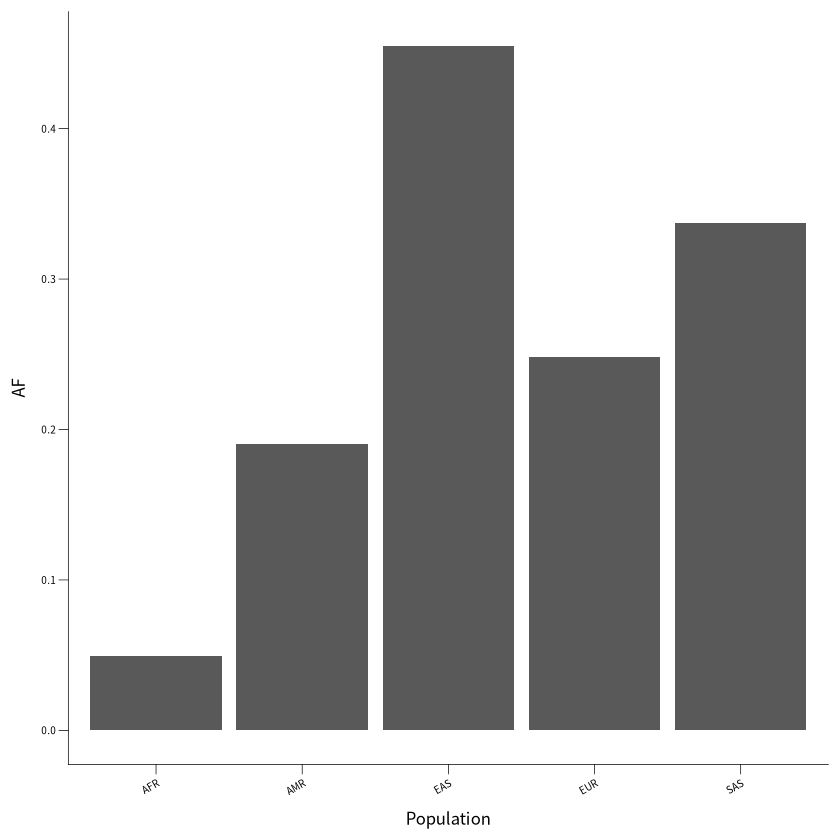

In [55]:
p <- ggplot(plot_df, aes(x = Population, y = AF)) +
  geom_bar(stat = "identity") + mytheme
p

In [56]:
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/cis/MAF_RNASE3.pdf',p)

Saving 7 x 7 in image
